# Replication completion timing bounds

This notebook prepares replication-timing profiles, fits initiation-rate landscapes, runs stochastic replication simulations, and compares empirical completion statistics with the analytical bounds of Alkhaled et al. (2026).

1. **Analysis A:** UCSC/ENCODE chromosome profiles fitted and simulated non-periodically, with empirical completion evaluated on a buffered chromosome interior against the full-line bound for the periodically extended initiation landscape.
2. **Analysis B:** HCT116 chromosome 8 windows treated as synthetic periodic domains.

Data acquisition and timing-profile construction are implemented in `replication_data_sources.py`; fitting, simulation, bounds, and plotting are implemented in `replication_src.py`.


## Imports

Load the numerical and plotting packages together with the two project modules.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from replication_src import *
from replication_data_sources import *

# Analysis A: chromosome-interior comparison with the full-line bound

Initiation-rate fitting and simulation use the observed chromosome with `perQ=False`. For the completion-time comparison, the fitted profile is continued periodically as a coefficient on $\mathbb{R}$ and the unchanged full-line theorem is compared with the empirical maximum over a buffered chromosome interior. Finite propagation makes this comparison valid while the reported times remain below the buffer-crossing horizon $b/v$.


## A1. Load UCSC Repli-seq signal

Select the ENCODE/UW cell lines and chromosomes, download any missing UCSC WaveSignal BigWigs, load them as 1 kb arrays, and cache raw timing CSVs. WaveSignal is already a single wavelet-smoothed replication-timing profile, so no S-phase reconstruction is required. The centromere intervals configured here are applied only when an analysis is run.


In [2]:
UCSC_REPLISEQ_BASE_URL = "http://hgdownload.soe.ucsc.edu/goldenPath/hg19/encodeDCC/wgEncodeUwRepliSeq"
REPLISEQ_REPLICATE = 1
REPLISEQ_CHROMS = ["chr1"]
REPLISEQ_RESOLUTION = 1_000
REPLISEQ_OVERWRITE_BIGWIG = False
REPLISEQ_OVERWRITE_TIMING_CACHE = False

UCSC_REPLISEQ_CELL_LINE_NAMES = {
    "BG02ES": "Bg02es",
    "BJ": "Bj",
    "HELAS3": "Helas3",
    "HEPG2": "Hepg2",
    "HUVEC": "Huvec",
    "IMR90": "Imr90",
    "K562": "K562",
    "MCF7": "Mcf7",
    "NHEK": "Nhek",
    "SKNSH": "Sknsh",
}
REPLISEQ_CELL_LINES = list(UCSC_REPLISEQ_CELL_LINE_NAMES)
REPLISEQ_CENTROMERES_BP = [(115_000_000, 145_000_000)]


In [3]:
REPLISEQ_BIGWIGS = download_ucsc_repliseq_wavelet_bigwigs(
    cell_lines=REPLISEQ_CELL_LINES,
    base_url=UCSC_REPLISEQ_BASE_URL,
    replicate=REPLISEQ_REPLICATE,
    data_dir=DATA_DIR,
    overwrite=REPLISEQ_OVERWRITE_BIGWIG,
    cell_line_names=UCSC_REPLISEQ_CELL_LINE_NAMES,
)

display(ucsc_repliseq_bigwig_status_table(
    REPLISEQ_BIGWIGS,
    replicate=REPLISEQ_REPLICATE,
))

Already available: data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig


,cell_line,replicate,local_bigwig,exists
0,BG02ES,1,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...,True
1,BJ,1,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig,True
2,HELAS3,1,data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bi...,True
3,HEPG2,1,data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig,True
4,HUVEC,1,data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig,True
5,IMR90,1,data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig,True
6,K562,1,data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig,True
7,MCF7,1,data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig,True
8,NHEK,1,data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig,True
9,SKNSH,1,data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig,True


In [4]:
INTERVAL_PROFILE_DATASETS, REPLISEQ_WAVELET_ARRAYS, interval_timing_summary = build_ucsc_repliseq_interval_datasets(
    cell_lines=REPLISEQ_CELL_LINES,
    chroms=REPLISEQ_CHROMS,
    resolution=REPLISEQ_RESOLUTION,
    replicate=REPLISEQ_REPLICATE,
    data_dir=DATA_DIR,
    timing_dir=TIMING_DIR,
    overwrite_timing_cache=REPLISEQ_OVERWRITE_TIMING_CACHE,
    cell_line_names=UCSC_REPLISEQ_CELL_LINE_NAMES,
)
INTERVAL_KEY = next(iter(INTERVAL_PROFILE_DATASETS))
repliseq_wavelet_signal = REPLISEQ_WAVELET_ARRAYS[INTERVAL_KEY]["signal"]
repliseq_wavelet_positions = REPLISEQ_WAVELET_ARRAYS[INTERVAL_KEY]["positions"]
repliseq_wavelet_bigwig = REPLISEQ_WAVELET_ARRAYS[INTERVAL_KEY]["bigwig"]

display(interval_timing_summary)
display(timing_cache_table(INTERVAL_PROFILE_DATASETS))

,key,cell_line,chromosome,resolution_bp,bins,centromere_interpolated_bins,centromere_interpolated_bp,source_bigwig,raw_timing_csv
0,BG02ES_interval_chr1,BG02ES,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...,timing\BG02ES_ucsc_wavelet_interval_profile_ch...
1,BJ_interval_chr1,BJ,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig,timing\BJ_ucsc_wavelet_interval_profile_chr1_0...
2,HELAS3_interval_chr1,HELAS3,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bi...,timing\HELAS3_ucsc_wavelet_interval_profile_ch...
3,HEPG2_interval_chr1,HEPG2,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig,timing\HEPG2_ucsc_wavelet_interval_profile_chr...
4,HUVEC_interval_chr1,HUVEC,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig,timing\HUVEC_ucsc_wavelet_interval_profile_chr...
5,IMR90_interval_chr1,IMR90,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig,timing\IMR90_ucsc_wavelet_interval_profile_chr...
6,K562_interval_chr1,K562,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig,timing\K562_ucsc_wavelet_interval_profile_chr1...
7,MCF7_interval_chr1,MCF7,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig,timing\MCF7_ucsc_wavelet_interval_profile_chr1...
8,NHEK_interval_chr1,NHEK,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig,timing\NHEK_ucsc_wavelet_interval_profile_chr1...
9,SKNSH_interval_chr1,SKNSH,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig,timing\SKNSH_ucsc_wavelet_interval_profile_chr...


,dataset_key,dataset_label,raw_timing_csv,exists
0,BG02ES_interval_chr1,"BG02ES, chr1 UCSC Repli-seq finite interval",timing\BG02ES_ucsc_wavelet_interval_profile_ch...,True
1,BJ_interval_chr1,"BJ, chr1 UCSC Repli-seq finite interval",timing\BJ_ucsc_wavelet_interval_profile_chr1_0...,True
2,HELAS3_interval_chr1,"HELAS3, chr1 UCSC Repli-seq finite interval",timing\HELAS3_ucsc_wavelet_interval_profile_ch...,True
3,HEPG2_interval_chr1,"HEPG2, chr1 UCSC Repli-seq finite interval",timing\HEPG2_ucsc_wavelet_interval_profile_chr...,True
4,HUVEC_interval_chr1,"HUVEC, chr1 UCSC Repli-seq finite interval",timing\HUVEC_ucsc_wavelet_interval_profile_chr...,True
5,IMR90_interval_chr1,"IMR90, chr1 UCSC Repli-seq finite interval",timing\IMR90_ucsc_wavelet_interval_profile_chr...,True
6,K562_interval_chr1,"K562, chr1 UCSC Repli-seq finite interval",timing\K562_ucsc_wavelet_interval_profile_chr1...,True
7,MCF7_interval_chr1,"MCF7, chr1 UCSC Repli-seq finite interval",timing\MCF7_ucsc_wavelet_interval_profile_chr1...,True
8,NHEK_interval_chr1,"NHEK, chr1 UCSC Repli-seq finite interval",timing\NHEK_ucsc_wavelet_interval_profile_chr1...,True
9,SKNSH_interval_chr1,"SKNSH, chr1 UCSC Repli-seq finite interval",timing\SKNSH_ucsc_wavelet_interval_profile_chr...,True


## A2. Run one chromosome-interior analysis

Select one cached UCSC profile and run the non-periodic fit and simulation. `INTERVAL_ANALYSIS_BOUND_GEOMETRY="line"` uses the unchanged full-line theorem for the periodically extended initiation profile. The empirical completion statistic is restricted to positions at least `INTERVAL_ANALYSIS_INTERIOR_BUFFER_BP` from each chromosome end, and the code verifies that the theoretical and empirical $T_\varepsilon$ curves remain within $b/v$. Missing values are interpolated before resampling and smoothing. The corrected centromere timing is fitted over the complete chromosome; centromere bins are excluded only from empirical target summaries.

The source grid is 1 kb. `refine_factor=1` preserves it, while `refine_factor=.1` produces a 10 kb simulation grid. Supply fork speed in kb/min; `run_single_dataset` converts it to grid sites/min.


In [7]:
INTERVAL_ANALYSIS_CELL_LINE = "BG02ES"
INTERVAL_ANALYSIS_CHROM = "chr1"
INTERVAL_ANALYSIS_BOUND_GEOMETRY = "line"
INTERVAL_ANALYSIS_INTERIOR_BUFFER_BP = 3_000_000

INTERVAL_ANALYSIS_CELL_LINE_KEY = str(INTERVAL_ANALYSIS_CELL_LINE).upper().replace("-", "").replace("_", "").replace(" ", "")
INTERVAL_KEY = f"{INTERVAL_ANALYSIS_CELL_LINE_KEY}_interval_{safe_filename(INTERVAL_ANALYSIS_CHROM)}"

if INTERVAL_KEY not in INTERVAL_PROFILE_DATASETS:
    available = ", ".join(INTERVAL_PROFILE_DATASETS)
    raise KeyError(f"{INTERVAL_KEY} is not available. Available keys: {available}")

if INTERVAL_ANALYSIS_BOUND_GEOMETRY not in {"interval", "line"}:
    raise ValueError("INTERVAL_ANALYSIS_BOUND_GEOMETRY must be 'interval' or 'line'.")

interval_selected_cfg = dict(INTERVAL_PROFILE_DATASETS[INTERVAL_KEY])
interval_selected_cfg["bound_geometries"] = [INTERVAL_ANALYSIS_BOUND_GEOMETRY]
interval_selected_cfg.pop("line_extension", None)
if INTERVAL_ANALYSIS_BOUND_GEOMETRY == "line":
    interval_selected_cfg.pop("boundary_conditions", None)
    interval_selected_cfg["line_extension"] = "periodic"
    interval_selected_cfg["label"] = f"{interval_selected_cfg['cell_line']}, {interval_selected_cfg['chrom']} chromosome interior (b={INTERVAL_ANALYSIS_INTERIOR_BUFFER_BP / 1e6:g} Mb)"
else:
    interval_selected_cfg["boundary_conditions"] = "zero_inflow"
display(pd.DataFrame([{
    "key": INTERVAL_KEY,
    "cell_line": interval_selected_cfg["cell_line"],
    "chromosome": interval_selected_cfg["chrom"],
    "resolution_bp": interval_selected_cfg["resolution"],
    "source_bigwig": interval_selected_cfg["source_bigwig"],
    "bound_geometry": INTERVAL_ANALYSIS_BOUND_GEOMETRY,
    "interior_buffer_bp": INTERVAL_ANALYSIS_INTERIOR_BUFFER_BP,
}]))

INTERVAL_ANALYSIS_SIM_NUMBER = 10_000
INTERVAL_ANALYSIS_REFINE_FACTOR = .1
INTERVAL_ANALYSIS_SMOOTH_WINDOW = 100
INTERVAL_ANALYSIS_TIMING_RANGE = (550, 30)
INTERVAL_ANALYSIS_EPS_GRID = np.geomspace(1e-2, 0.99, 100)
INTERVAL_ANALYSIS_NUM_T_BOUND = 4_000
INTERVAL_ANALYSIS_MAX_REP_TIME = 2_000

interval_result = run_single_dataset(
    interval_selected_cfg,
    fork_speed_kb_min=1.4,
    sim_number=INTERVAL_ANALYSIS_SIM_NUMBER,
    refine_factor=INTERVAL_ANALYSIS_REFINE_FACTOR,
    smooth_window=INTERVAL_ANALYSIS_SMOOTH_WINDOW,
    timing_range=INTERVAL_ANALYSIS_TIMING_RANGE,
    eps_grid=INTERVAL_ANALYSIS_EPS_GRID,
    num_t_bound=INTERVAL_ANALYSIS_NUM_T_BOUND,
    max_rep_time=INTERVAL_ANALYSIS_MAX_REP_TIME,
    timing_cache_mode="load",
    centromeres_bp=REPLISEQ_CENTROMERES_BP,
    empirical_interior_buffer_bp=(
        INTERVAL_ANALYSIS_INTERIOR_BUFFER_BP
        if INTERVAL_ANALYSIS_BOUND_GEOMETRY == "line" else None
    ),
)

,key,cell_line,chromosome,resolution_bp,source_bigwig,bound_geometry,interior_buffer_bp
0,BG02ES_interval_chr1,BG02ES,chr1,1000,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...,line,3000000


Processing: BG02ES, chr1 chromosome interior (b=3 Mb)
Region: chr1:0-249250000
Model periodicity: fit=False, simulation=False
Bound geometries: ['line']
Loading raw timing CSV: timing\BG02ES_ucsc_wavelet_interval_profile_chr1_0_249250000_res1000_raw_timing.csv
Centromere override: set 3,000 bins to pre-rescale maximum for timing minimum 77.9983 (30 min after rescaling)
Grid spacing: 10 kb per simulation site
Fork speed: 1.4 kb/min = 0.14 grid sites/min
Empirical target: ignoring 3,000 centromere bins in empirical target summaries; the theoretical bound uses the complete fitted domain
Empirical target: chromosome interior 3-246.25 Mb with a 3 Mb buffer at each end
Interior comparison horizon: 2142.86 min; largest compared T_epsilon: 1323.08 min


## A3. Plot and summarize the selected result

Plot the fitted initiation rate, prepared Repli-seq timing versus simulated mean timing, and the full-line theoretical $T_\varepsilon$ bound versus the empirical chromosome-interior statistic. The expected-time table is retained as a numerical full-line reference; the finite-horizon interior argument does not certify its infinite-time comparison.


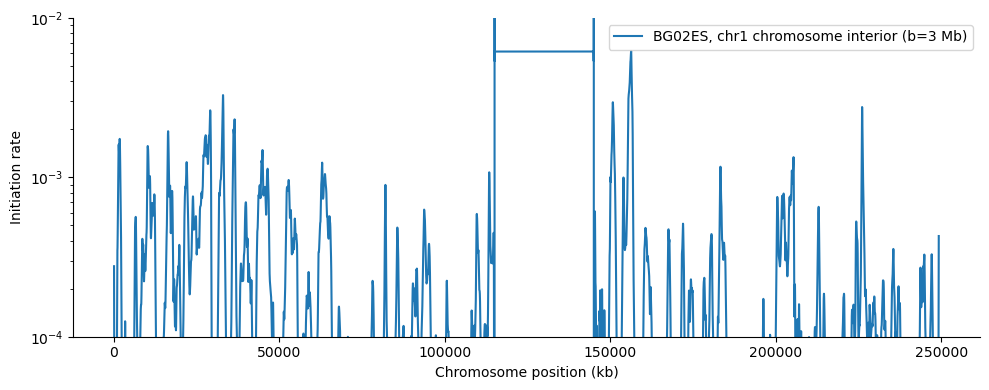

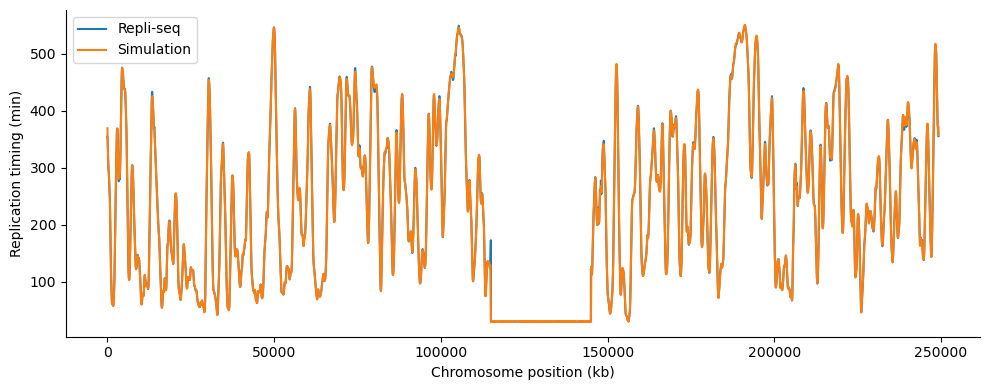

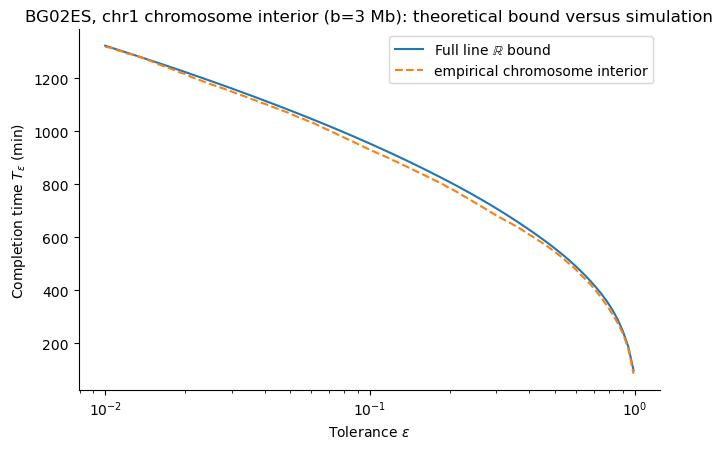

,dataset_key,dataset_label,geometry,dx_kb,fork_speed_kb_min,fork_speed_grid_per_min,E_theory_min,tail_fraction,empirical_interior_buffer_bp,expected_time_comparison_certified,E_empirical_pointwise_min,theory_over_empirical_pointwise
0,BG02ES_interval_chr1,"BG02ES, chr1 chromosome interior (b=3 Mb)",line,10.0,1.4,0.14,584.221322,0.0,3000000.0,False,550.428459,1.061394


In [8]:
make_standard_plots(
    interval_result,
    save_figures=False,
    initiation_ylims=(1e-4, 1e-2),

)

expected_time_summary_table({INTERVAL_KEY: interval_result})

## A4. Compare UCSC cell lines on chromosome 1

Run the selected chr1 cell lines with independent versions of the A2 controls. The `"line"` setting uses the periodically extended full-line model and an empirical chromosome interior, while `"interval"` uses the finite non-periodic domain. The full-line expected-time comparison remains a numerical reference because the finite-horizon interior argument applies only to $T_\varepsilon$.


In [9]:
INTERVAL_BATCH_CELL_LINES = REPLISEQ_CELL_LINES

INTERVAL_BATCH_CHROM = "chr1"
INTERVAL_BATCH_BOUND_GEOMETRY = "line"
INTERVAL_BATCH_INTERIOR_BUFFER_BP = 3_000_000
INTERVAL_BATCH_FORK_SPEED_KB_MIN = 1.4
INTERVAL_BATCH_SIM_NUMBER = 1000
INTERVAL_BATCH_REFINE_FACTOR = globals().get("INTERVAL_ANALYSIS_REFINE_FACTOR", .1)
INTERVAL_BATCH_SMOOTH_WINDOW = globals().get("INTERVAL_ANALYSIS_SMOOTH_WINDOW", 100)
INTERVAL_BATCH_TIMING_RANGE = globals().get("INTERVAL_ANALYSIS_TIMING_RANGE", (550, 30))
INTERVAL_BATCH_EPS_GRID = globals().get("INTERVAL_ANALYSIS_EPS_GRID", np.geomspace(1e-2, 0.99, 100))
INTERVAL_BATCH_NUM_T_BOUND = globals().get("INTERVAL_ANALYSIS_NUM_T_BOUND", 4_000)
INTERVAL_BATCH_MAX_REP_TIME = globals().get("INTERVAL_ANALYSIS_MAX_REP_TIME", 2_000)

INTERVAL_BATCH_KEYS = [
    f"{str(cell_line).upper().replace('-', '').replace('_', '').replace(' ', '')}_interval_{safe_filename(INTERVAL_BATCH_CHROM)}"
    for cell_line in INTERVAL_BATCH_CELL_LINES
]
missing_interval_batch_keys = [key for key in INTERVAL_BATCH_KEYS if key not in INTERVAL_PROFILE_DATASETS]
if missing_interval_batch_keys:
    available = ", ".join(INTERVAL_PROFILE_DATASETS)
    missing = ", ".join(missing_interval_batch_keys)
    raise KeyError(f"Missing batch dataset key(s): {missing}. Available keys: {available}")

if INTERVAL_BATCH_BOUND_GEOMETRY not in {"interval", "line"}:
    raise ValueError("INTERVAL_BATCH_BOUND_GEOMETRY must be 'interval' or 'line'.")

INTERVAL_BATCH_DATASETS = {}
for key in INTERVAL_BATCH_KEYS:
    cfg = dict(INTERVAL_PROFILE_DATASETS[key])
    cfg["bound_geometries"] = [INTERVAL_BATCH_BOUND_GEOMETRY]
    cfg.pop("line_extension", None)
    if INTERVAL_BATCH_BOUND_GEOMETRY == "line":
        cfg.pop("boundary_conditions", None)
        cfg["line_extension"] = "periodic"
        cfg["label"] = f"{cfg['cell_line']}, {cfg['chrom']} chromosome interior (b={INTERVAL_BATCH_INTERIOR_BUFFER_BP / 1e6:g} Mb)"
    else:
        cfg["boundary_conditions"] = "zero_inflow"
    INTERVAL_BATCH_DATASETS[key] = cfg
display(pd.DataFrame([
    {
        "key": key,
        "cell_line": cfg["cell_line"],
        "chromosome": cfg["chrom"],
        "resolution_bp": cfg["resolution"],
        "source_bigwig": cfg["source_bigwig"],
        "bound_geometry": INTERVAL_BATCH_BOUND_GEOMETRY,
        "interior_buffer_bp": (
            INTERVAL_BATCH_INTERIOR_BUFFER_BP
            if INTERVAL_BATCH_BOUND_GEOMETRY == "line" else None
        ),
    }
    for key, cfg in INTERVAL_BATCH_DATASETS.items()
]))

interval_batch_results = run_dataset_collection(
    INTERVAL_BATCH_DATASETS,
    selected_keys=INTERVAL_BATCH_KEYS,
    fork_speed_kb_min=INTERVAL_BATCH_FORK_SPEED_KB_MIN,
    sim_number=INTERVAL_BATCH_SIM_NUMBER,
    refine_factor=INTERVAL_BATCH_REFINE_FACTOR,
    smooth_window=INTERVAL_BATCH_SMOOTH_WINDOW,
    timing_range=INTERVAL_BATCH_TIMING_RANGE,
    eps_grid=INTERVAL_BATCH_EPS_GRID,
    num_t_bound=INTERVAL_BATCH_NUM_T_BOUND,
    max_rep_time=INTERVAL_BATCH_MAX_REP_TIME,
    timing_cache_mode="load",
    centromeres_bp=REPLISEQ_CENTROMERES_BP,
    empirical_interior_buffer_bp=(
        INTERVAL_BATCH_INTERIOR_BUFFER_BP
        if INTERVAL_BATCH_BOUND_GEOMETRY == "line" else None
    ),
)

,key,cell_line,chromosome,resolution_bp,source_bigwig,bound_geometry,interior_buffer_bp
0,BG02ES_interval_chr1,BG02ES,chr1,1000,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...,line,3000000
1,BJ_interval_chr1,BJ,chr1,1000,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig,line,3000000
2,HELAS3_interval_chr1,HELAS3,chr1,1000,data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bi...,line,3000000
3,HEPG2_interval_chr1,HEPG2,chr1,1000,data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig,line,3000000
4,HUVEC_interval_chr1,HUVEC,chr1,1000,data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig,line,3000000
5,IMR90_interval_chr1,IMR90,chr1,1000,data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig,line,3000000
6,K562_interval_chr1,K562,chr1,1000,data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig,line,3000000
7,MCF7_interval_chr1,MCF7,chr1,1000,data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig,line,3000000
8,NHEK_interval_chr1,NHEK,chr1,1000,data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig,line,3000000
9,SKNSH_interval_chr1,SKNSH,chr1,1000,data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig,line,3000000


Processing: BG02ES, chr1 chromosome interior (b=3 Mb)
Region: chr1:0-249250000
Model periodicity: fit=False, simulation=False
Bound geometries: ['line']
Loading raw timing CSV: timing\BG02ES_ucsc_wavelet_interval_profile_chr1_0_249250000_res1000_raw_timing.csv
Centromere override: set 3,000 bins to pre-rescale maximum for timing minimum 77.9983 (30 min after rescaling)
Grid spacing: 10 kb per simulation site
Fork speed: 1.4 kb/min = 0.14 grid sites/min
Empirical target: ignoring 3,000 centromere bins in empirical target summaries; the theoretical bound uses the complete fitted domain
Empirical target: chromosome interior 3-246.25 Mb with a 3 Mb buffer at each end
Interior comparison horizon: 2142.86 min; largest compared T_epsilon: 1392.55 min
Processing: BJ, chr1 chromosome interior (b=3 Mb)
Region: chr1:0-249250000
Model periodicity: fit=False, simulation=False
Bound geometries: ['line']
Loading raw timing CSV: timing\BJ_ucsc_wavelet_interval_profile_chr1_0_249250000_res1000_raw_timi

KeyboardInterrupt: 

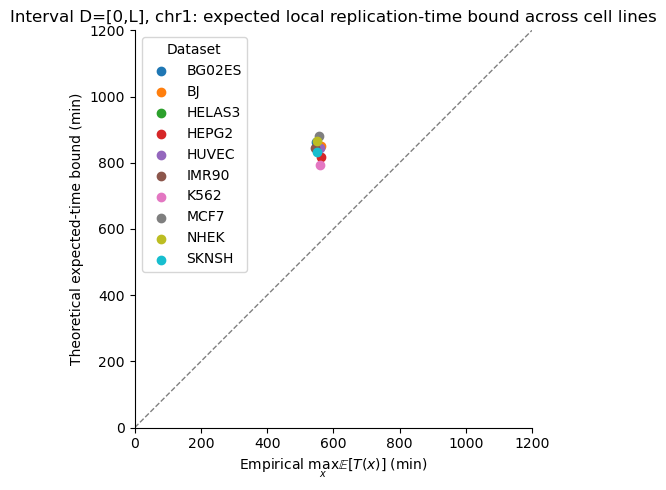

In [ ]:
INTERVAL_BATCH_SCATTER_XLIMS = (0, 800)
INTERVAL_BATCH_SCATTER_YLIMS = (0, 800)
INTERVAL_BATCH_SAVE_PDF = True

if INTERVAL_BATCH_BOUND_GEOMETRY == "line":
    INTERVAL_BATCH_SCATTER_TITLE = f"Full-line expected-time reference vs {INTERVAL_BATCH_CHROM} empirical interior, b={INTERVAL_BATCH_INTERIOR_BUFFER_BP / 1e6:g} Mb"
    INTERVAL_BATCH_SCATTER_XLABEL = r"Empirical interior $\max_x \mathbb{E}[T(x)]$ (min)"
    INTERVAL_BATCH_SCATTER_YLABEL = "Full-line expected-time bound (min)"
    INTERVAL_BATCH_SCATTER_FILENAME = f"full_line_vs_interior_expected_time_pairs_{safe_filename(INTERVAL_BATCH_CHROM)}.pdf"
else:
    INTERVAL_BATCH_SCATTER_TITLE = f"Finite-interval expected-time bound vs {INTERVAL_BATCH_CHROM} empirical target"
    INTERVAL_BATCH_SCATTER_XLABEL = r"Empirical target $\max_x \mathbb{E}[T(x)]$ (min)"
    INTERVAL_BATCH_SCATTER_YLABEL = r"Finite-interval $D=[0,L]$ expected-time bound (min)"
    INTERVAL_BATCH_SCATTER_FILENAME = f"finite_interval_expected_time_pairs_{safe_filename(INTERVAL_BATCH_CHROM)}.pdf"

fig, ax, interval_expected_time_pairs = plot_expected_time_pair_scatter(
    interval_batch_results,
    title=INTERVAL_BATCH_SCATTER_TITLE,
    label_col="cell_line",
    xlims=INTERVAL_BATCH_SCATTER_XLIMS,
    ylims=INTERVAL_BATCH_SCATTER_YLIMS,
    xlabel=INTERVAL_BATCH_SCATTER_XLABEL,
    ylabel=INTERVAL_BATCH_SCATTER_YLABEL,
)
if INTERVAL_BATCH_SAVE_PDF:
    fig.savefig(
        FIGURE_DIR / INTERVAL_BATCH_SCATTER_FILENAME,
        bbox_inches="tight",
    )
plt.show()

# Analysis B: periodic HCT116 chromosome 8 windows

The three chromosome 8 windows defined below use HCT116 Repli-seq data from Zhao et al. (GSE137764) and regions motivated by Jaworski et al. Each window is analyzed as a synthetic circular domain for comparison with the torus bound, not as a purified ecDNA Repli-seq measurement.


## B1. Prepare Zhao HCT116 timing profiles

Download the processed 50 kb HCT116 matrix, calculate a weighted S1-S16 phase index in each source bin, and linearly interpolate each selected window onto a 1 kb analysis grid. The interpolation provides the simulation grid but does not increase the measurement resolution. Cache one timing CSV per window.


In [ ]:
ZHAO_HCT116_GSE_ACCESSION = DEFAULT_ZHAO_HCT116_GSE_ACCESSION
ZHAO_HCT116_REPLISEQ_URL = DEFAULT_ZHAO_HCT116_REPLISEQ_URL
ZHAO_HCT116_REPLISEQ_GZ = DATA_DIR / DEFAULT_ZHAO_HCT116_REPLISEQ_FILENAME_GZ
ZHAO_HCT116_REPLISEQ_TABLE = DATA_DIR / DEFAULT_ZHAO_HCT116_REPLISEQ_FILENAME
ZHAO_HCT116_SOURCE_RESOLUTION = DEFAULT_ZHAO_HCT116_SOURCE_RESOLUTION
ZHAO_HCT116_ANALYSIS_RESOLUTION = DEFAULT_ZHAO_HCT116_ANALYSIS_RESOLUTION
ZHAO_HCT116_S_PHASE_BINS = DEFAULT_ZHAO_HCT116_S_PHASE_BINS
ZHAO_HCT116_OVERWRITE_DOWNLOAD = False
ZHAO_HCT116_OVERWRITE_TIMING_CACHE = False

zhao_hct116_table_path = ensure_zhao_hct116_repliseq(
    url=ZHAO_HCT116_REPLISEQ_URL,
    gz_path=ZHAO_HCT116_REPLISEQ_GZ,
    table_path=ZHAO_HCT116_REPLISEQ_TABLE,
    overwrite=ZHAO_HCT116_OVERWRITE_DOWNLOAD,
)
zhao_hct116_matrix = load_zhao_hct116_repliseq_matrix(
    path=zhao_hct116_table_path,
    s_phase_bins=ZHAO_HCT116_S_PHASE_BINS,
    source_resolution=ZHAO_HCT116_SOURCE_RESOLUTION,
)

PERIODIC_CELL_LINES = ["HCT116"]
PERIODIC_REGIONS = [
    {
        "region_id": "CHR8_CMYC_7MB",
        "label": "chr8 c-MYC/ecDNA context window",
        "short_label": "chr8 c-MYC/ecDNA 7 Mb",
        "chrom": "chr8",
        "start": 124_000_000,
        "end": 130_775_000,
    },
    {
        "region_id": "CHR8_ECDNA_DOMINANT",
        "label": "chr8 dominant ecDNA-derived interval",
        "short_label": "chr8 dominant ecDNA interval",
        "chrom": "chr8",
        "start": 126_425_747,
        "end": 128_512_820,
    },
    {
        "region_id": "CHR8_CMYC_ORIGIN_ZOOM",
        "label": "chr8 c-MYC-centred origin-density zoom",
        "short_label": "chr8 c-MYC origin zoom",
        "chrom": "chr8",
        "start": 127_675_747,
        "end": 127_875_747,
    },
]

PERIODIC_INTERVAL_DATASETS = build_zhao_hct116_periodic_configs(
    PERIODIC_REGIONS,
    resolution=ZHAO_HCT116_ANALYSIS_RESOLUTION,
    accession=ZHAO_HCT116_GSE_ACCESSION,
    source_resolution=ZHAO_HCT116_SOURCE_RESOLUTION,
    cell_line="HCT116",
)

display(pd.DataFrame([
    {
        "key": key,
        "cell_line": cfg["cell_line"],
        "region": cfg["short_label"].replace(f"{cfg['cell_line']} ", ""),
        "coordinates": f"{cfg.get('requested_chrom', cfg['chrom'])}:{cfg['start']}-{cfg['end']}",
        "source_resolution_bp": cfg["source_resolution"],
        "analysis_resolution_bp": cfg["resolution"],
    }
    for key, cfg in PERIODIC_INTERVAL_DATASETS.items()
]))

display(timing_cache_table(PERIODIC_INTERVAL_DATASETS))

periodic_timing_preprocessing = preprocess_zhao_hct116_timing_collection(
    PERIODIC_INTERVAL_DATASETS,
    zhao_hct116_matrix,
    overwrite=ZHAO_HCT116_OVERWRITE_TIMING_CACHE,
)
display(periodic_timing_preprocessing)

## B2. Run one periodic-window analysis

Select one cached window and run periodic smoothing, initiation-rate fitting, and simulation with `perQ=True`, followed by the torus-bound calculation. `refine_factor=1` preserves the cached 1 kb analysis grid.


In [ ]:
PERIODIC_EXAMPLE_CELL_LINE = "HCT116"
PERIODIC_EXAMPLE_REGION_ID = "CHR8_CMYC_ORIGIN_ZOOM"
PERIODIC_KEY = f"{PERIODIC_EXAMPLE_CELL_LINE}_{PERIODIC_EXAMPLE_REGION_ID}"

if PERIODIC_KEY not in PERIODIC_INTERVAL_DATASETS:
    available = ", ".join(PERIODIC_INTERVAL_DATASETS)
    raise KeyError(f"{PERIODIC_KEY} is not available. Available keys: {available}")

periodic_result = run_single_dataset(
    PERIODIC_INTERVAL_DATASETS[PERIODIC_KEY],
    fork_speed_kb_min=1.4,
    sim_number=10_000,
    refine_factor=1,
    smooth_window=10,
    timing_range=(60, 10),
    eps_grid=np.geomspace(1e-2, 0.99, 100),
    num_t_bound=4_000,
    max_rep_time=2_000,
    timing_cache_mode="load",
)

## B3. Plot and summarize the selected result

Plot the periodic initiation rate, prepared HCT116 timing versus simulated mean timing, and torus bound versus empirical $T_\varepsilon$. Then report the expected-time summary.


In [ ]:
make_standard_plots(
    periodic_result,
    save_figures=False,
)

expected_time_summary_table({PERIODIC_KEY: periodic_result})

## B4. Compare the three periodic windows

Run all three HCT116 windows with the batch settings below and compare empirical $\max_x \mathbb{E}[T(x)]$ with the torus expected-time bound.


In [ ]:
PERIODIC_BATCH_DATASETS = PERIODIC_INTERVAL_DATASETS

periodic_batch_results = run_dataset_collection(
    PERIODIC_BATCH_DATASETS,
    selected_keys=list(PERIODIC_BATCH_DATASETS),
    fork_speed_kb_min=1.4,
    sim_number=1000,
    refine_factor=1,
    smooth_window=50,
    timing_range=(60, 10),
    eps_grid=np.geomspace(1e-2, 0.99, 100),
    num_t_bound=4_000,
    max_rep_time=2_000,
    timing_cache_mode="load",
)

In [ ]:
fig, ax, periodic_expected_time_pairs = plot_expected_time_pair_scatter(
    periodic_batch_results,
    title="Torus: expected local replication-time bound for HCT116 chr8 finite windows",
    xlims=(0, 100),
    ylims=(0, 100),
)
fig.savefig(FIGURE_DIR / "hct116_chr8_three_windows_torus_expected_time_pairs.pdf", bbox_inches="tight")
plt.show()

# Notes on interpretation

Analysis A fits and simulates one chromosome non-periodically. The theoretical calculation applies the unchanged full-line theorem to the periodically continued fitted initiation landscape. Empirical completion is evaluated only on the buffered chromosome interior, excluding configured centromere targets, and is certified only when the complete theoretical and empirical $T_\varepsilon$ range lies below $b/v$. The expected-time comparison is retained only as a numerical full-line reference because it integrates beyond this finite validity horizon.

Analysis B circularizes each selected HCT116 genomic window. Periodic smoothing, fitting, simulation, and torus local-mass calculations therefore wrap across the window boundary. These profiles are derived from genomic HCT116 Repli-seq data and should not be interpreted as direct ecDNA measurements.

Both workflows convert physical fork speed to grid units using

$$
v_{\mathrm{grid}} = \frac{v_{\mathrm{kb/min}}}{dx_{\mathrm{kb}}}.
$$

The expected-time bound is obtained by integrating the completion-time survival bound. In Analysis B it is compared on the matching torus geometry; in Analysis A its comparison with the empirical slowest interior mean is explicitly treated as a numerical reference. Initiation-rate fitting follows [Berkemeier et al. (2025)](https://www.nature.com/articles/s41467-025-59991-w); full references for the data and completion bounds are listed in the README.
